# FMATCH 9/10 — Runners: manifest in, product out

**PR topic**: the operational entry points that make FMATCH a pipeline step.

- `_runner.py` — the shared workflow: read the input **manifest**, resolve the
  staged ancillary tree (`$FMATCH_ANCILLARY_PATH/<reader_key>/…`), select the L1B
  granule(s) by product ID, load them (`load_l1b_radiometer_inputs` /
  `load_l1b_camera_dataset`), run the assembly from the previous PRs, and write the
  conformant [NetCDF](https://www.unidata.ucar.edu/software/netcdf/) product plus an **output manifest** into `$PROCESSING_PATH`.
- Five thin per-product modules (`fmatch_cam`, `fmatch_cam_camtime`,
  `fmatch_imager`, `fmatch_imager_camtime`, `fmatch_imager_flash`), each just a
  `FmatchRunnerConfig` + CLI `main` — one [Docker image](https://docs.docker.com/reference/dockerfile/), dispatched by [entry point](https://packaging.python.org/en/latest/specifications/entry-points/).
- The `footprint_matching/Dockerfile` and `scripts/generate_fmatch_example_products.py`
  (bulk example-product generation used for end-to-end exercises).

This is the PR where the FMATCH feature becomes *complete*: the integration test
(`tests/integration/test_fmatch_runner.py`) drives the same path you see below, and
the deferred `test_product.py` (whose camtime helpers need `_runner`'s L1B loaders)
lands here too.

In [1]:
import os
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from libera_utils.footprint_matching import fmatch_cam, fmatch_cam_camtime
from libera_utils.footprint_matching._runner import ANCILLARY_PATH_ENV
from libera_utils.io.manifest import Manifest, ManifestType
from tests.test_data.footprint_matching.fixtures import (
    make_era5_netcdf_fixture,
    make_l1b_camera_fixture,
    make_l1b_radiometer_fixture,
    make_viirs_brdf_hdf5_fixture,
    make_viirs_cloud_d3_fixture,
)

## Setup: a synthetic processing environment

The runners read everything from the environment, exactly like the operational
container: `PROCESSING_PATH` is the output dropbox and `FMATCH_ANCILLARY_PATH` is
the staged ancillary tree with one directory per reader key. We stage **real
synthetic granules** for `era5`, `viirs_cloud`, and `viirs_brdf`, and deliberately
leave `igbp`/`nise` unstaged to show the non-strict degradation (their product
columns fall back to fill, visibly, instead of failing the granule).

In [3]:
work = Path(tempfile.mkdtemp(prefix="fmatch_nb09_"))
inputs = work / "inputs"
dropbox = work / "dropbox"
ancillary = work / "ancillary"
for d in (inputs, dropbox, ancillary):
    d.mkdir()
os.environ["PROCESSING_PATH"] = str(dropbox)
os.environ[ANCILLARY_PATH_ENV] = str(ancillary)

(ancillary / "era5").mkdir()
make_era5_netcdf_fixture(ancillary / "era5", lat_min=-90, lat_max=90, lon_min=-180, lon_max=180, n_lat=91, n_lon=181)
(ancillary / "viirs_cloud").mkdir()
make_viirs_cloud_d3_fixture(
    ancillary / "viirs_cloud", n_lat=90, n_lon=180, lat_min=-89.5, lat_max=89.5, lon_min=-179.5, lon_max=179.5
)
(ancillary / "viirs_brdf").mkdir()
make_viirs_brdf_hdf5_fixture(
    ancillary / "viirs_brdf", n_lat=180, n_lon=360, lat_min=-89.5, lat_max=89.5, lon_min=-179.5, lon_max=179.5
)
print("staged:", sorted(p.name for p in ancillary.iterdir()))

staged: ['era5', 'viirs_brdf', 'viirs_cloud']


## 1. The input manifest

Upstream pipeline steps hand each runner a manifest listing its inputs; the runner
selects the files it needs by Libera product ID parsed from the filename.

In [4]:
l1b_file = make_l1b_radiometer_fixture(inputs, n_footprints=40)
manifest = Manifest(manifest_type=ManifestType.INPUT)
manifest.add_files(l1b_file)
manifest_path = manifest.write(inputs)
print(f"L1B input : {l1b_file.name}")
print(f"manifest  : {Path(manifest_path).name}")

L1B input : LIBERA_L1B_RAD-4CH_V1-0-0_20260611T000000_20260611T000000_R26254174441.nc
manifest  : LIBERA_INPUT_MANIFEST_01M28S4NQAHV30T5SW94VYXBZC.json


## 2. Run the FMATCH-CAM runner end to end

`fmatch_cam.algorithm` is exactly what the container entry point calls.

In [5]:
output_manifest_path = fmatch_cam.algorithm(Path(manifest_path))
output_manifest = Manifest.from_file(output_manifest_path)
product_path = output_manifest.files[0].filename
print(f"output manifest: {Path(str(output_manifest_path)).name}  ({output_manifest.manifest_type})")
print(f"product        : {Path(str(product_path)).name}")

2026-09-11 17:44:41,967 INFO      [libera_utils.logutil:logutil.py:388 in configure_task_logging()]: Console logging configured at level 20.


2026-09-11 17:44:41,967 INFO      [libera_utils.footprint_matching._runner:_runner.py:246 in run_algorithm()]: Step 1: Reading the input manifest file


2026-09-11 17:44:41,967 INFO      [libera_utils.footprint_matching._runner:_runner.py:249 in run_algorithm()]: Loaded manifest with 1 files


2026-09-11 17:44:41,968 INFO      [libera_utils.footprint_matching._runner:_runner.py:250 in run_algorithm()]: Running FMATCH-CAM


2026-09-11 17:44:41,968 INFO      [libera_utils.footprint_matching._runner:_runner.py:265 in run_algorithm()]: Step 2: Locating staged ancillary inputs


...

2026-09-11 17:44:42,159 INFO      [libera_utils.footprint_matching._runner:_runner.py:292 in run_algorithm()]: Step 5: Creating the output manifest


2026-09-11 17:44:42,159 INFO      [libera_utils.footprint_matching._runner:_runner.py:296 in run_algorithm()]: Step 6: Adding 1 data file(s) to the output manifest


2026-09-11 17:44:42,160 INFO      [libera_utils.footprint_matching._runner:_runner.py:300 in run_algorithm()]: Step 7: Writing the output manifest


2026-09-11 17:44:42,160 INFO      [libera_utils.footprint_matching._runner:_runner.py:302 in run_algorithm()]: Output manifest written to: /tmp/fmatch_nb09_msdoet2h/dropbox/LIBERA_OUTPUT_MANIFEST_01M28S4NQAHV30T5SW94VYXBZC.json


output manifest: LIBERA_OUTPUT_MANIFEST_01M28S4NQAHV30T5SW94VYXBZC.json  (OUTPUT)
product        : LIBERA_AUX_FMATCH-CAM_V5-8-5_20260611T000000_20260611T000000_R26254174441.nc


dims: {'RADIOMETER_TIME': 40}
InputGranules: LIBERA_L1B_RAD-4CH_V1-0-0_20260611T000000_20260611T000000_R26254174441.nc


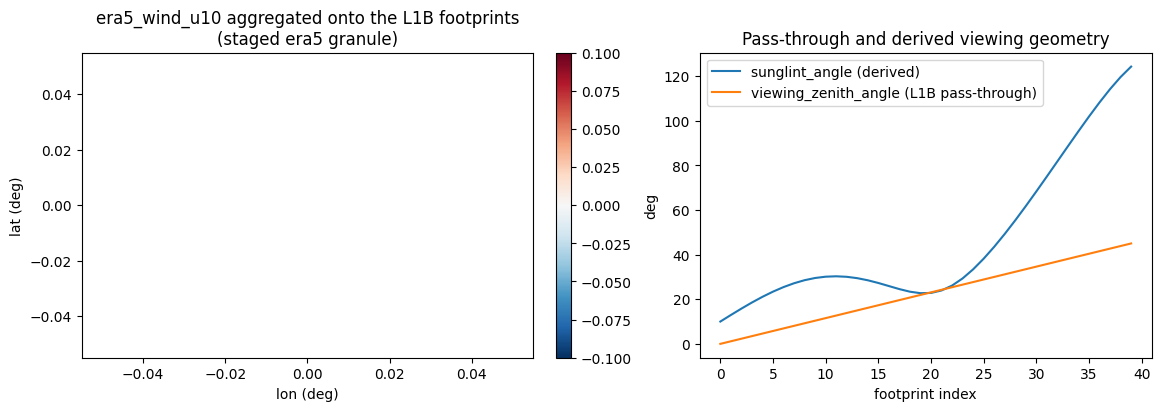

In [6]:
product = xr.open_dataset(product_path)
print(f"dims: {dict(product.sizes)}")
print(f"InputGranules: {product.attrs['InputGranules']}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4), constrained_layout=True)
sc = ax1.scatter(product.longitude, product.latitude, c=product.era5_wind_u10, s=14, cmap="RdBu_r")
ax1.set_title("era5_wind_u10 aggregated onto the L1B footprints\n(staged era5 granule)")
ax1.set_xlabel("lon (deg)")
ax1.set_ylabel("lat (deg)")
fig.colorbar(sc, ax=ax1)

ax2.plot(product.sunglint_angle.values, label="sunglint_angle (derived)")
ax2.plot(product.viewing_zenith_angle.values, label="viewing_zenith_angle (L1B pass-through)")
ax2.set_xlabel("footprint index")
ax2.set_ylabel("deg")
ax2.legend()
ax2.set_title("Pass-through and derived viewing geometry")
plt.show()

The unstaged sources degrade visibly rather than failing:

In [7]:
staged_var = float(np.isfinite(product.era5_wind_u10.values).mean())
unstaged = product.igbp_surface_type.values
print(f"era5_wind_u10 finite fraction      : {staged_var:.2f}  (staged granule)")
print(f"igbp_surface_type unique values    : {np.unique(unstaged)}  (unstaged -> fill)")
print(f"coverage QA flags present          : {'qa_coverage' in product or 'coverage' in ''.join(product.data_vars)}")
product.close()

era5_wind_u10 finite fraction      : 0.00  (staged granule)
igbp_surface_type unique values    : [0]  (unstaged -> fill)
coverage QA flags present          : True


## 3. The camera-timescale runner

Same manifest pattern, different config: the CAM-CAMTIME runner opens the L1B
*camera* granule, segments it into pseudo-footprints (PR 8), and writes the
`FOOTPRINT`-axis product.

In [8]:
cam_inputs = work / "cam_inputs"
cam_inputs.mkdir()
l1b_cam = make_l1b_camera_fixture(cam_inputs, n_images=2, n_pixels_x=5, n_pixels_y=5)
cam_manifest = Manifest(manifest_type=ManifestType.INPUT)
cam_manifest.add_files(l1b_cam)
cam_manifest_path = cam_manifest.write(cam_inputs)

camtime_output = Manifest.from_file(fmatch_cam_camtime.algorithm(Path(str(cam_manifest_path))))
with xr.open_dataset(camtime_output.files[0].filename) as camtime_product:
    print(f"product dims : {dict(camtime_product.sizes)}")
    print(
        f"CAMERA_TIME repeats per image: {len(camtime_product.CAMERA_TIME.values)} records, "
        f"{len(np.unique(camtime_product.CAMERA_TIME.values))} unique times"
    )

2026-09-11 17:44:42,333 INFO      [libera_utils.logutil:logutil.py:388 in configure_task_logging()]: Console logging configured at level 20.


2026-09-11 17:44:42,333 INFO      [libera_utils.footprint_matching._runner:_runner.py:246 in run_algorithm()]: Step 1: Reading the input manifest file


2026-09-11 17:44:42,333 INFO      [libera_utils.footprint_matching._runner:_runner.py:249 in run_algorithm()]: Loaded manifest with 1 files


2026-09-11 17:44:42,333 INFO      [libera_utils.footprint_matching._runner:_runner.py:250 in run_algorithm()]: Running FMATCH-CAM-CAMTIME


2026-09-11 17:44:42,333 INFO      [libera_utils.footprint_matching._runner:_runner.py:265 in run_algorithm()]: Step 2: Locating staged ancillary inputs


...

2026-09-11 17:44:42,558 INFO      [libera_utils.footprint_matching._runner:_runner.py:292 in run_algorithm()]: Step 5: Creating the output manifest


2026-09-11 17:44:42,558 INFO      [libera_utils.footprint_matching._runner:_runner.py:296 in run_algorithm()]: Step 6: Adding 1 data file(s) to the output manifest


2026-09-11 17:44:42,559 INFO      [libera_utils.footprint_matching._runner:_runner.py:300 in run_algorithm()]: Step 7: Writing the output manifest


2026-09-11 17:44:42,559 INFO      [libera_utils.footprint_matching._runner:_runner.py:302 in run_algorithm()]: Output manifest written to: /tmp/fmatch_nb09_msdoet2h/dropbox/LIBERA_OUTPUT_MANIFEST_01M28S4P2WA008QGA767F9HNKC.json


product dims : {'CAMERA_TIME': 2, 'FOOTPRINT': 25}
CAMERA_TIME repeats per image: 2 records, 2 unique times


## 4. One image, five runners

All five FMATCH products share `_runner.py` and one Docker image
(`libera_utils/footprint_matching/Dockerfile`); the entry point picks the config:

In [9]:
from libera_utils.footprint_matching import fmatch_imager, fmatch_imager_camtime, fmatch_imager_flash

for module in (fmatch_cam, fmatch_cam_camtime, fmatch_imager, fmatch_imager_camtime, fmatch_imager_flash):
    cfg = module.RUNNER_CONFIG
    print(f"{cfg.output_product_id.value:26s} mode={cfg.mode.name:15s} l1b_input={cfg.l1b_input_product_id.value}")

FMATCH-CAM                 mode=CAM             l1b_input=RAD-4CH
FMATCH-CAM-CAMTIME         mode=CAM_CAMTIME     l1b_input=CAM
FMATCH-IMAGER              mode=IMAGER          l1b_input=RAD-4CH
FMATCH-IMAGER-CAMTIME      mode=IMAGER_CAMTIME  l1b_input=CAM
FMATCH-IMAGER-FLASH        mode=IMAGER_FLASH    l1b_input=RAD-4CH


## Where this goes next in the stack

FMATCH is now feature-complete: `pytest tests/integration/test_fmatch_runner.py`
exercises these paths against the same fixtures. The final PR of the stack adds the
**Scene-ID imager family**, which consumes the FMATCH-IMAGER products this runner
writes. For a bulk demonstration over a synthetic day, see
`scripts/generate_fmatch_example_products.py`.